In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
ac_df               = pd.read_csv("../../00_input/external financing/수정주가.csv", index_col = "Date", parse_dates = True)
mkt_cap             = pd.read_csv("../../00_input/external financing/mkt_cap.csv", index_col = "Date", parse_dates = True)
pbr                 = pd.read_csv("../../00_input/external financing/pbr.csv", index_col = "Date", parse_dates = True)
debt_short          = pd.read_csv("../../00_input/external financing/단기차입부채.csv", index_col = "Date", parse_dates = True)
debt_long           = pd.read_csv("../../00_input/external financing/장기차입부채.csv", index_col = "Date", parse_dates = True)
total_asset         = pd.read_csv("../../00_input/external financing/KOSPI_KOSDAQ_total_asset.csv", index_col = "Date", parse_dates = True)
issuance_equity     = pd.read_csv("../../00_input/external financing/equity issuance.csv", index_col = "Date", parse_dates = True)
factors             = pd.read_csv('../../00_input/Factors.csv', index_col='Date', parse_dates=True)

C:\Users\XH58\AppData\Local\Temp\ipykernel_88564\83085723.py:5: DtypeWarning: Columns (3672) have mixed types. Specify dtype option on import or set low_memory=False.
  debt_long           = pd.read_csv("../../00_input/external financing/장기차입부채.csv", index_col = "Date", parse_dates = True)


In [45]:
# 전처리 함수 정의
def make_ff_factors(factors, annual_rf=True):
    """
    factors: DataFrame with columns ['KOSPI','SMB','HML','MOM','RF']
    """
    
    df = factors.copy()

    # 0. resampling
    df = df.resample('ME').last()
    
    # 1. 지수 → 수익률 변환
    ret_cols = ['KOSPI','SMB','HML','MOM']
    df[ret_cols] = df[ret_cols].pct_change()
    
    # 2. 무위험금리 변환 (연율 → 일/월 수익률)
    df['RF'] = df['RF'] / 100  # % → 소수화 (예: 3.5% → 0.035)
    df['RF'] = (1 + df['RF']) ** (1/12) - 1
    
    # 4. 컬럼 정리
    df = df[['KOSPI','SMB','HML','MOM','RF']].dropna()
    
    return df

In [46]:
factors_monthly = make_ff_factors(factors)[:-1]

In [47]:
monthly_returns = ac_df.resample('ME').last().pct_change(fill_method = None)
monthly_mkt_cap = mkt_cap.resample('ME').last()
monthly_pbr = pbr.resample('ME').last()
monthly_debt_short = debt_short.resample('ME').last()               # lag 필요
monthly_debt_long = debt_long.resample('ME').last()                 # lag 필요
monthly_total_asset = total_asset.resample('ME').last()             # lag 필요
monthly_issuance_equity = issuance_equity.resample('ME').last()

# 연말(12월) 값으로 해당 연도의 모든 월말 데이터 fill
year_end_values = monthly_issuance_equity[monthly_issuance_equity.index.month == 12]
for year in year_end_values.index.year.unique():
    dec_date = year_end_values.index[year_end_values.index.year == year][0]
    monthly_issuance_equity.loc[monthly_issuance_equity.index.year == year] = year_end_values.loc[dec_date].values

In [48]:
monthly_debt_short = monthly_debt_short.shift(14)
monthly_debt_long = monthly_debt_long.shift(14)
monthly_total_asset = monthly_total_asset.shift(14)

In [49]:
monthly_issuance_equity

,삼성전자,SK하이닉스,현대차,LG에너지솔루션,한화에어로스페이스,SK스퀘어,삼성바이오로직스,두산에너빌리티,기아,HD현대중공업,...,웨이포트,성융광전투자유한공사,완리,골든센츄리,평산차업,네프로아이티,중국고섬,SBI모기지,SBI핀테크솔루션즈,SNK
Date,,,,,,,,,,,,,,,,,,,,,
1993-12-31,4.772723e+07,0.0,40130915.0,0.0,11215386.0,0.0,0.0,0.0,65288215.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1994-01-31,5.153240e+07,0.0,40130915.0,0.0,13284227.0,0.0,0.0,0.0,72352387.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1994-02-28,5.153240e+07,0.0,40130915.0,0.0,13284227.0,0.0,0.0,0.0,72352387.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1994-03-31,5.153240e+07,0.0,40130915.0,0.0,13284227.0,0.0,0.0,0.0,72352387.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1994-04-30,5.153240e+07,0.0,40130915.0,0.0,13284227.0,0.0,0.0,0.0,72352387.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,5.866262e+09,690241698.0,202042642.0,234000000.0,49055525.0,132091250.0,67151809.0,640465168.0,389759751.0,90147996.0,...,0.0,0.0,0.0,201363884.0,0.0,0.0,0.0,0.0,22961922.0,21061797.0
2025-12-31,5.866262e+09,690241698.0,202042642.0,234000000.0,49055525.0,132091250.0,67151809.0,640465168.0,389759751.0,90147996.0,...,0.0,0.0,0.0,201363884.0,0.0,0.0,0.0,0.0,22961922.0,21061797.0
2026-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
# pbr이 0.2 이하이면 NaN으로 대체
monthly_pbr[monthly_pbr <= 0.2] = pd.NA

In [51]:
total_debt = monthly_debt_short + monthly_debt_long

In [52]:
monthly_equity_issuance_delta = monthly_issuance_equity - monthly_issuance_equity.shift(12)
total_debt_delta = total_debt.shift(12)
avg_assets = (monthly_total_asset + monthly_total_asset.shift(12)) / 2

In [53]:
factor = monthly_equity_issuance_delta / avg_assets + monthly_equity_issuance_delta / avg_assets

In [54]:
# 윈저라이징: 팩터를 월별 크로스섹션 기준 상·하위 1%로 클리핑 (Residual_MAX 스타일)
factor_clean = factor.replace([np.inf, -np.inf], np.nan)
wins_threshold = 0.01
factor_w = factor_clean.clip(
    lower=factor_clean.quantile(wins_threshold, axis=1),
    upper=factor_clean.quantile(1 - wins_threshold, axis=1),
    axis=0
)
factor_m = factor_w  # 팩터는 이미 월말 기준

# 월별 리밸런싱: 월말 리스트 및 수익률
ret_m = monthly_returns
# 백테스트 기간, 월말 리스트
start_date = '2009-12-31'
end_date   = '2025-12-31'
month_ends = pd.date_range(start=start_date, end=end_date, freq='ME').tolist()

# 하위 N% 종목 선택 (팩터 값이 작은 순)
def select_bottom_pct(fac_series, pct=0.2):
    f_t = fac_series.dropna()
    if len(f_t) == 0:
        return []
    n_sel = max(1, int(len(f_t) * pct))
    return f_t.nlargest(n_sel).index.tolist()

bottom_pct = 0.1  # 하위 20% (원하면 0.1, 0.3 등으로 변경)

# 월말 리밸런싱 — 팩터 기준 하위 N% 종목, 다음 달 수익률로 포트폴리오 수익
portfolio_ret = pd.Series(index=month_ends[1:], dtype=float)

for i in range(0, len(month_ends) - 1):
    rebal_start = month_ends[i]
    rebal_end   = month_ends[i + 1]
    sel = select_bottom_pct(factor_m.loc[rebal_start], pct=bottom_pct)
    if sel:
        r = ret_m.loc[rebal_end, ret_m.columns.intersection(sel)].dropna()
        portfolio_ret.loc[rebal_end] = r.mean() if not r.empty else np.nan
    else:
        portfolio_ret.loc[rebal_end] = np.nan

In [55]:
# 월별 리밸런싱: 월말 리스트 및 수익률
ret_m = monthly_returns
# 백테스트 기간, 월말 리스트
start_date = '2009-12-31'
end_date   = '2025-12-31'
month_ends = pd.date_range(start=start_date, end=end_date, freq='ME').tolist()

def select_top20(fac_series, n=20):
    f_t = fac_series.dropna()
    n_sel = min(n, len(f_t))
    return f_t.nlargest(n_sel).index.tolist() if n_sel else []

# 월말 리밸런싱 — 윈저라이징된 팩터 기준 상위 20종목, 다음 달 수익률로 포트폴리오 수익
portfolio_ret = pd.Series(index=month_ends[1:], dtype=float)

for i in range(0, len(month_ends) - 1):
    rebal_start = month_ends[i]
    rebal_end   = month_ends[i + 1]
    # if rebal_start not in factor_m.index or rebal_end not in ret_m.index:
    #     continue
    sel = select_top20(factor_m.loc[rebal_start])
    if sel:
        r = ret_m.loc[rebal_end, ret_m.columns.intersection(sel)].dropna()
        portfolio_ret.loc[rebal_end] = r.mean() if not r.empty else np.nan

# common_idx = pd.date_range(start=month_ends[0], end=month_ends[-1], freq='ME')
# portfolio_ret = portfolio_ret.reindex(common_idx, fill_value=0)

In [56]:
# 포트폴리오 NAV (월 수익률 누적)
portfolio_nav = (1 + portfolio_ret.fillna(0)).cumprod()
portfolio_nav

2010-01-31     1.042294
2010-02-28     1.076281
2010-03-31     1.301170
2010-04-30     1.206189
2010-05-31     1.114073
                ...    
2025-08-31    15.651179
2025-09-30    18.126827
2025-10-31    17.595791
2025-11-30    19.250982
2025-12-31    19.344691
Length: 192, dtype: float64

<Axes: >

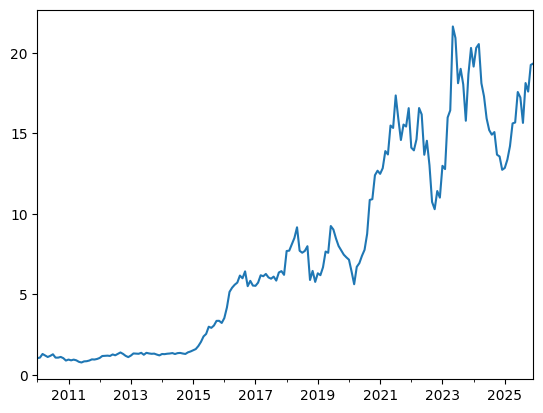

In [57]:
portfolio_nav.plot()

In [58]:
# CAGR 계산
years = (portfolio_nav.index[-1] - portfolio_nav.index[0]).days / 365.25
cagr  = portfolio_nav.iloc[-1] ** (1 / years) - 1
print(f'CAGR: {cagr:.2%}')

# 연 환산 변동성 계산
volatility = portfolio_ret.std() * np.sqrt(12)
print(f'Annualized Volatility: {volatility:.2%}')

# Sharpe Ratio 계산 (무위험 수익률 연 2% 반영)
risk_free_rate = (1 + 0.02) ** (1 / 12) - 1          
excess_returns = portfolio_ret - risk_free_rate
sharpe_ratio   = excess_returns.mean() / excess_returns.std() * np.sqrt(12)
print(f'Sharpe Ratio: {sharpe_ratio:.2f}')


CAGR: 20.46%
Annualized Volatility: 30.81%
Sharpe Ratio: 0.69


In [59]:
import statsmodels.api as sm

# 팩터 데이터 불러오기
factors = factors_monthly

# 포트폴리오 수익률을 DataFrame으로 변환
portfolio_df = portfolio_ret.to_frame(name='Return')

# 1. 두 데이터 공통 구간 맞추기
df = pd.concat([portfolio_df, factors], axis=1, join="inner").dropna()

In [60]:
# 2. 종속변수: 포트폴리오 초과수익률
y = df['Return'] - df['RF']

# 3. 독립변수: MKT, SMB, HML, MOM
X = pd.DataFrame({
    "MKT": df['KOSPI'] - df['RF'],
    "SMB": df['SMB'],
    "HML": df['HML'],
    "MOM": df['MOM']
}, index=df.index)

X = sm.add_constant(X, has_constant='add')

# 4. OLS 회귀
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})  # Newey-West 표준오차
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.423
Method:                 Least Squares   F-statistic:                     45.12
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.74e-26
Time:                        03:03:44   Log-Likelihood:                 247.33
No. Observations:                 192   AIC:                            -484.7
Df Residuals:                     187   BIC:                            -468.4
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0148      0.005      2.970      0.0

## 5분위 포트폴리오 백테스트


In [61]:
quantile_labels = [f'Q{i}' for i in range(1, 6)]
quantile_ret = pd.DataFrame(index=month_ends[1:], columns=quantile_labels, dtype=float)

for i in range(0, len(month_ends) - 1):
    rebal_start = month_ends[i]
    rebal_end = month_ends[i + 1]

    if rebal_start not in factor_m.index or rebal_end not in ret_m.index:
        continue

    factor_slice = factor_m.loc[rebal_start].replace([np.inf, -np.inf], np.nan).dropna()
    future_ret = ret_m.loc[rebal_end].dropna()
    common_stocks = factor_slice.index.intersection(future_ret.index)

    if len(common_stocks) < 5:
        continue

    factor_slice = factor_slice.loc[common_stocks]
    future_ret = future_ret.loc[common_stocks]

    ranks = factor_slice.rank(method='first')
    quantiles = pd.qcut(ranks, q=5, labels=quantile_labels)

    for label in quantile_labels:
        bucket = future_ret.loc[quantiles[quantiles == label].index]
        quantile_ret.loc[rebal_end, label] = bucket.mean() if not bucket.empty else np.nan

quantile_nav = (1 + quantile_ret.fillna(0)).cumprod()
quantile_spread = quantile_ret['Q5'] - quantile_ret['Q1']
quantile_summary = pd.DataFrame({
    'Mean Monthly Return': quantile_ret.mean(),
    'Volatility': quantile_ret.std(),
    'Sharpe (ann.)': ((quantile_ret.mean() - ((1 + 0.02) ** (1 / 12) - 1)) / quantile_ret.std()) * np.sqrt(12)
})

quantile_summary


,Mean Monthly Return,Volatility,Sharpe (ann.)
Q1,0.001634,0.049025,-0.001229
Q2,0.010865,0.054146,0.589444
Q3,0.009929,0.052209,0.549217
Q4,0.012346,0.059051,0.627391
Q5,0.010948,0.060138,0.535522


,Mean Monthly Return,Volatility,Sharpe (ann.)
Q1,0.16%,4.90%,-0.00
Q2,1.09%,5.41%,0.59
Q3,0.99%,5.22%,0.55
Q4,1.23%,5.91%,0.63
Q5,1.09%,6.01%,0.54


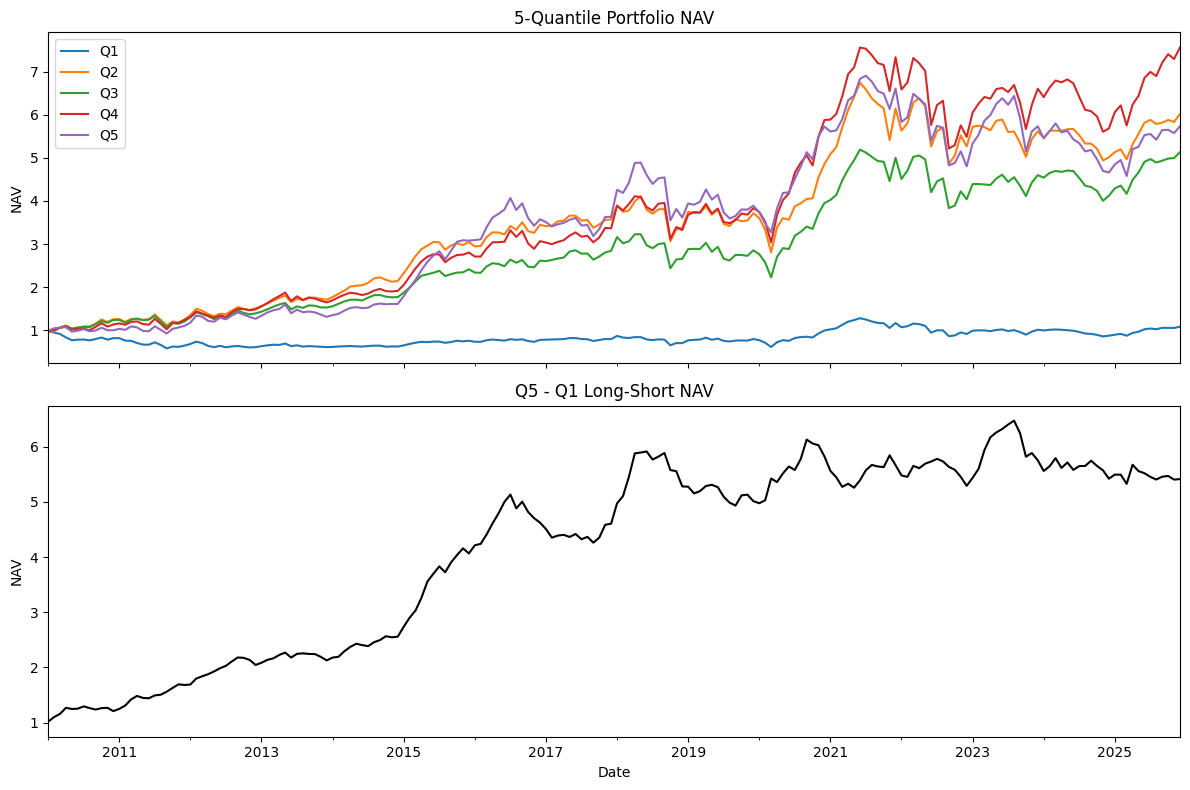

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

quantile_nav.plot(ax=axes[0])
axes[0].set_title('5-Quantile Portfolio NAV')
axes[0].set_ylabel('NAV')

spread_nav = (1 + quantile_spread.fillna(0)).cumprod()
spread_nav.plot(ax=axes[1], color='black')
axes[1].set_title('Q5 - Q1 Long-Short NAV')
axes[1].set_ylabel('NAV')
axes[1].set_xlabel('Date')

plt.tight_layout()

display(quantile_summary.style.format({
    'Mean Monthly Return': '{:.2%}',
    'Volatility': '{:.2%}',
    'Sharpe (ann.)': '{:.2f}'
}))
